# So sánh dữ liệu 3 người: Hiếu, Kiên, Tiến

Notebook này đọc dữ liệu trong `server/data` và so sánh theo đúng cấu trúc folder hiện tại:

- `Fall`: so sánh theo từng folder con như `NgaRaTruoc`, `NgaRaSau`, `LonXon`.
- `Normal`: cũng so sánh theo từng folder con của 3 người, ví dụ `DiBo`, `ChayBoCham`, `GoPhim`, `LuotDienThoai`.
- Trong cùng một người: so sánh time series theo cặp hoạt động `DiBo` với `ChayBoCham`, và `LuotDienThoai` với `GoPhim`.

Tên folder được chuẩn hóa nhẹ để xử lý các khác biệt như `lon`/`LonXon`, `ChayboCham`/`ChayBoCham`, `LuotDienthoai`/`LuotDienThoai`.


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import display

matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

BASE = os.path.join('..', 'server', 'data')
PERSON_ORDER = ['Hieu', 'Kien', 'Tien']
PERSON_DIRS = {name: os.path.join(BASE, name) for name in PERSON_ORDER}
COLOR_MAP = {
    'Hieu': '#1f77b4',
    'Kien': '#d62728',
    'Tien': '#2ca02c',
}
FALL_ACTIVITY_ORDER = ['NgaRaTruoc', 'NgaRaSau', 'LonXon', 'NgaNghienPhai', 'NgaNghiengTrai']
NORMAL_ACTIVITY_ORDER = ['DiBo', 'ChayBoCham', 'GoPhim', 'LuotDienThoai', 'LonXon']
FEATURE_COLS = ['magnitude_avg', 'sma', 'max_accel', 'max_gyro', 'std_accel', 'jerk_peak', 'bpm']
ACTIVITY_ALIASES = {
    'lon': 'LonXon',
    'LonXon': 'LonXon',
    'ChayboCham': 'ChayBoCham',
    'ChayBoCham': 'ChayBoCham',
    'LuotDienthoai': 'LuotDienThoai',
    'LuotDienThoai': 'LuotDienThoai',
    'NgaRaTruoc': 'NgaRaTruoc',
    'NgaRaSau': 'NgaRaSau',
    'NgaNghienPhai': 'NgaNghienPhai',
    'NgaNghiengPhai': 'NgaNghienPhai',
    'NgaNghiengTrai': 'NgaNghiengTrai',
    'DiBo': 'DiBo',
    'GoPhim': 'GoPhim',
}

def canonical_activity_name(name):
    return ACTIVITY_ALIASES.get(name, name)

def concat_or_empty(frames):
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def normalize_accel(df):
    required = {'accel_time_list', 'accel_x_list', 'accel_y_list', 'accel_z_list'}
    if not required.issubset(df.columns):
        return None
    out = df.rename(columns={
        'accel_time_list': 'time',
        'accel_x_list': 'ax',
        'accel_y_list': 'ay',
        'accel_z_list': 'az',
    }).copy()
    out['mag'] = np.sqrt(out['ax']**2 + out['ay']**2 + out['az']**2)
    return out

def normalize_gyro(df):
    required = {'gyro_time_list', 'gyro_x_list', 'gyro_y_list', 'gyro_z_list'}
    if not required.issubset(df.columns):
        return None
    out = df.rename(columns={
        'gyro_time_list': 'time',
        'gyro_x_list': 'gx',
        'gyro_y_list': 'gy',
        'gyro_z_list': 'gz',
    }).copy()
    out['gmag'] = np.sqrt(out['gx']**2 + out['gy']**2 + out['gz']**2)
    return out

def ordered_activities(label_type, activity_names):
    activity_names = sorted(set(activity_names))
    if label_type == 'Fall':
        preferred = FALL_ACTIVITY_ORDER
    else:
        preferred = NORMAL_ACTIVITY_ORDER
    ordered = [name for name in preferred if name in activity_names]
    extras = sorted(name for name in activity_names if name not in ordered)
    return ordered + extras

def load_person_data(person_dir, person_name):
    accel_frames = []
    gyro_frames = []
    feature_frames = []
    session_rows = []

    for label_type in ['Fall', 'Normal']:
        label_dir = os.path.join(person_dir, label_type)
        if not os.path.isdir(label_dir):
            continue

        for first_level in sorted(os.listdir(label_dir)):
            first_dir = os.path.join(label_dir, first_level)
            if not os.path.isdir(first_dir):
                continue

            direct_session = any(
                os.path.exists(os.path.join(first_dir, filename))
                for filename in ['accel.csv', 'gyro.csv', 'features.csv']
            )

            session_targets = []
            if direct_session:
                activity_name = canonical_activity_name(first_level)
                session_targets.append((activity_name, first_level, first_dir))
            else:
                activity_name = canonical_activity_name(first_level)
                for session_name in sorted(os.listdir(first_dir)):
                    session_dir = os.path.join(first_dir, session_name)
                    if os.path.isdir(session_dir):
                        session_targets.append((activity_name, session_name, session_dir))

            for activity_name, session_name, session_dir in session_targets:
                session_id = f'{activity_name}/{session_name}'
                accel_path = os.path.join(session_dir, 'accel.csv')
                gyro_path = os.path.join(session_dir, 'gyro.csv')
                feature_path = os.path.join(session_dir, 'features.csv')

                accel_count = 0
                gyro_count = 0
                feature_count = 0

                if os.path.exists(accel_path):
                    accel_df = normalize_accel(pd.read_csv(accel_path))
                    if accel_df is not None and not accel_df.empty:
                        accel_count = len(accel_df)
                        accel_df['person'] = person_name
                        accel_df['label_type'] = label_type
                        accel_df['activity_name'] = activity_name
                        accel_df['session'] = session_id
                        accel_frames.append(accel_df)

                if os.path.exists(gyro_path):
                    gyro_df = normalize_gyro(pd.read_csv(gyro_path))
                    if gyro_df is not None and not gyro_df.empty:
                        gyro_count = len(gyro_df)
                        gyro_df['person'] = person_name
                        gyro_df['label_type'] = label_type
                        gyro_df['activity_name'] = activity_name
                        gyro_df['session'] = session_id
                        gyro_frames.append(gyro_df)

                if os.path.exists(feature_path):
                    feature_df = pd.read_csv(feature_path)
                    if not feature_df.empty:
                        feature_count = len(feature_df)
                        feature_df['person'] = person_name
                        feature_df['label_type'] = label_type
                        feature_df['activity_name'] = activity_name
                        feature_df['session'] = session_id
                        feature_frames.append(feature_df)

                if accel_count or gyro_count or feature_count:
                    session_rows.append({
                        'person': person_name,
                        'label_type': label_type,
                        'activity_name': activity_name,
                        'session': session_id,
                        'n_accel_samples': accel_count,
                        'n_gyro_samples': gyro_count,
                        'n_feature_windows': feature_count,
                    })

    return {
        'accel': concat_or_empty(accel_frames),
        'gyro': concat_or_empty(gyro_frames),
        'features': concat_or_empty(feature_frames),
        'sessions': pd.DataFrame(session_rows),
    }


In [7]:
people_data = {name: load_person_data(path, name) for name, path in PERSON_DIRS.items()}
all_accel = concat_or_empty([people_data[name]['accel'] for name in PERSON_ORDER])
all_gyro = concat_or_empty([people_data[name]['gyro'] for name in PERSON_ORDER])
all_features = concat_or_empty([people_data[name]['features'] for name in PERSON_ORDER])
all_sessions = concat_or_empty([people_data[name]['sessions'] for name in PERSON_ORDER])

for name in PERSON_ORDER:
    sess_df = people_data[name]['sessions']
    accel_df = people_data[name]['accel']
    feat_df = people_data[name]['features']
    print(f'{name}: {len(sess_df)} sessions | {len(accel_df)} accel samples | {len(feat_df)} feature windows')

session_counts = (
    all_sessions
    .groupby(['label_type', 'activity_name', 'person'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=PERSON_ORDER, fill_value=0)
    .sort_index()
)
display(session_counts)

for label_type in ['Fall', 'Normal']:
    common_activities = sorted(set.intersection(*[
        set(all_sessions[(all_sessions['label_type'] == label_type) & (all_sessions['person'] == name)]['activity_name'].unique())
        for name in PERSON_ORDER
    ]))
    print(f'Hoat dong chung {label_type}:', common_activities if common_activities else 'Khong co')


Hieu: 105 sessions | 46800 accel samples | 468 feature windows
Kien: 93 sessions | 26600 accel samples | 266 feature windows
Tien: 95 sessions | 32100 accel samples | 321 feature windows


person                     Hieu  Kien  Tien
label_type activity_name                   
Fall       LonXon            10     7    12
           NgaNghienPhai      0     7     0
           NgaNghiengTrai     0     7     0
           NgaRaSau          16    14    20
           NgaRaTruoc        20    13    20
Normal     ChayBoCham        13    15    11
           DiBo               5    11    11
           GoPhim            10    10    11
           LonXon            21     0     0
           LuotDienThoai     10     9    10

Hoat dong chung Fall: ['LonXon', 'NgaRaSau', 'NgaRaTruoc']
Hoat dong chung Normal: ['ChayBoCham', 'DiBo', 'GoPhim', 'LuotDienThoai']


## So sánh `Fall` theo từng folder của 3 người

Ví dụ `NgaRaTruoc`: so sánh dữ liệu `NgaRaTruoc` của cả Hiếu, Kiên, Tiến. Tương tự cho các folder `Fall` còn lại.


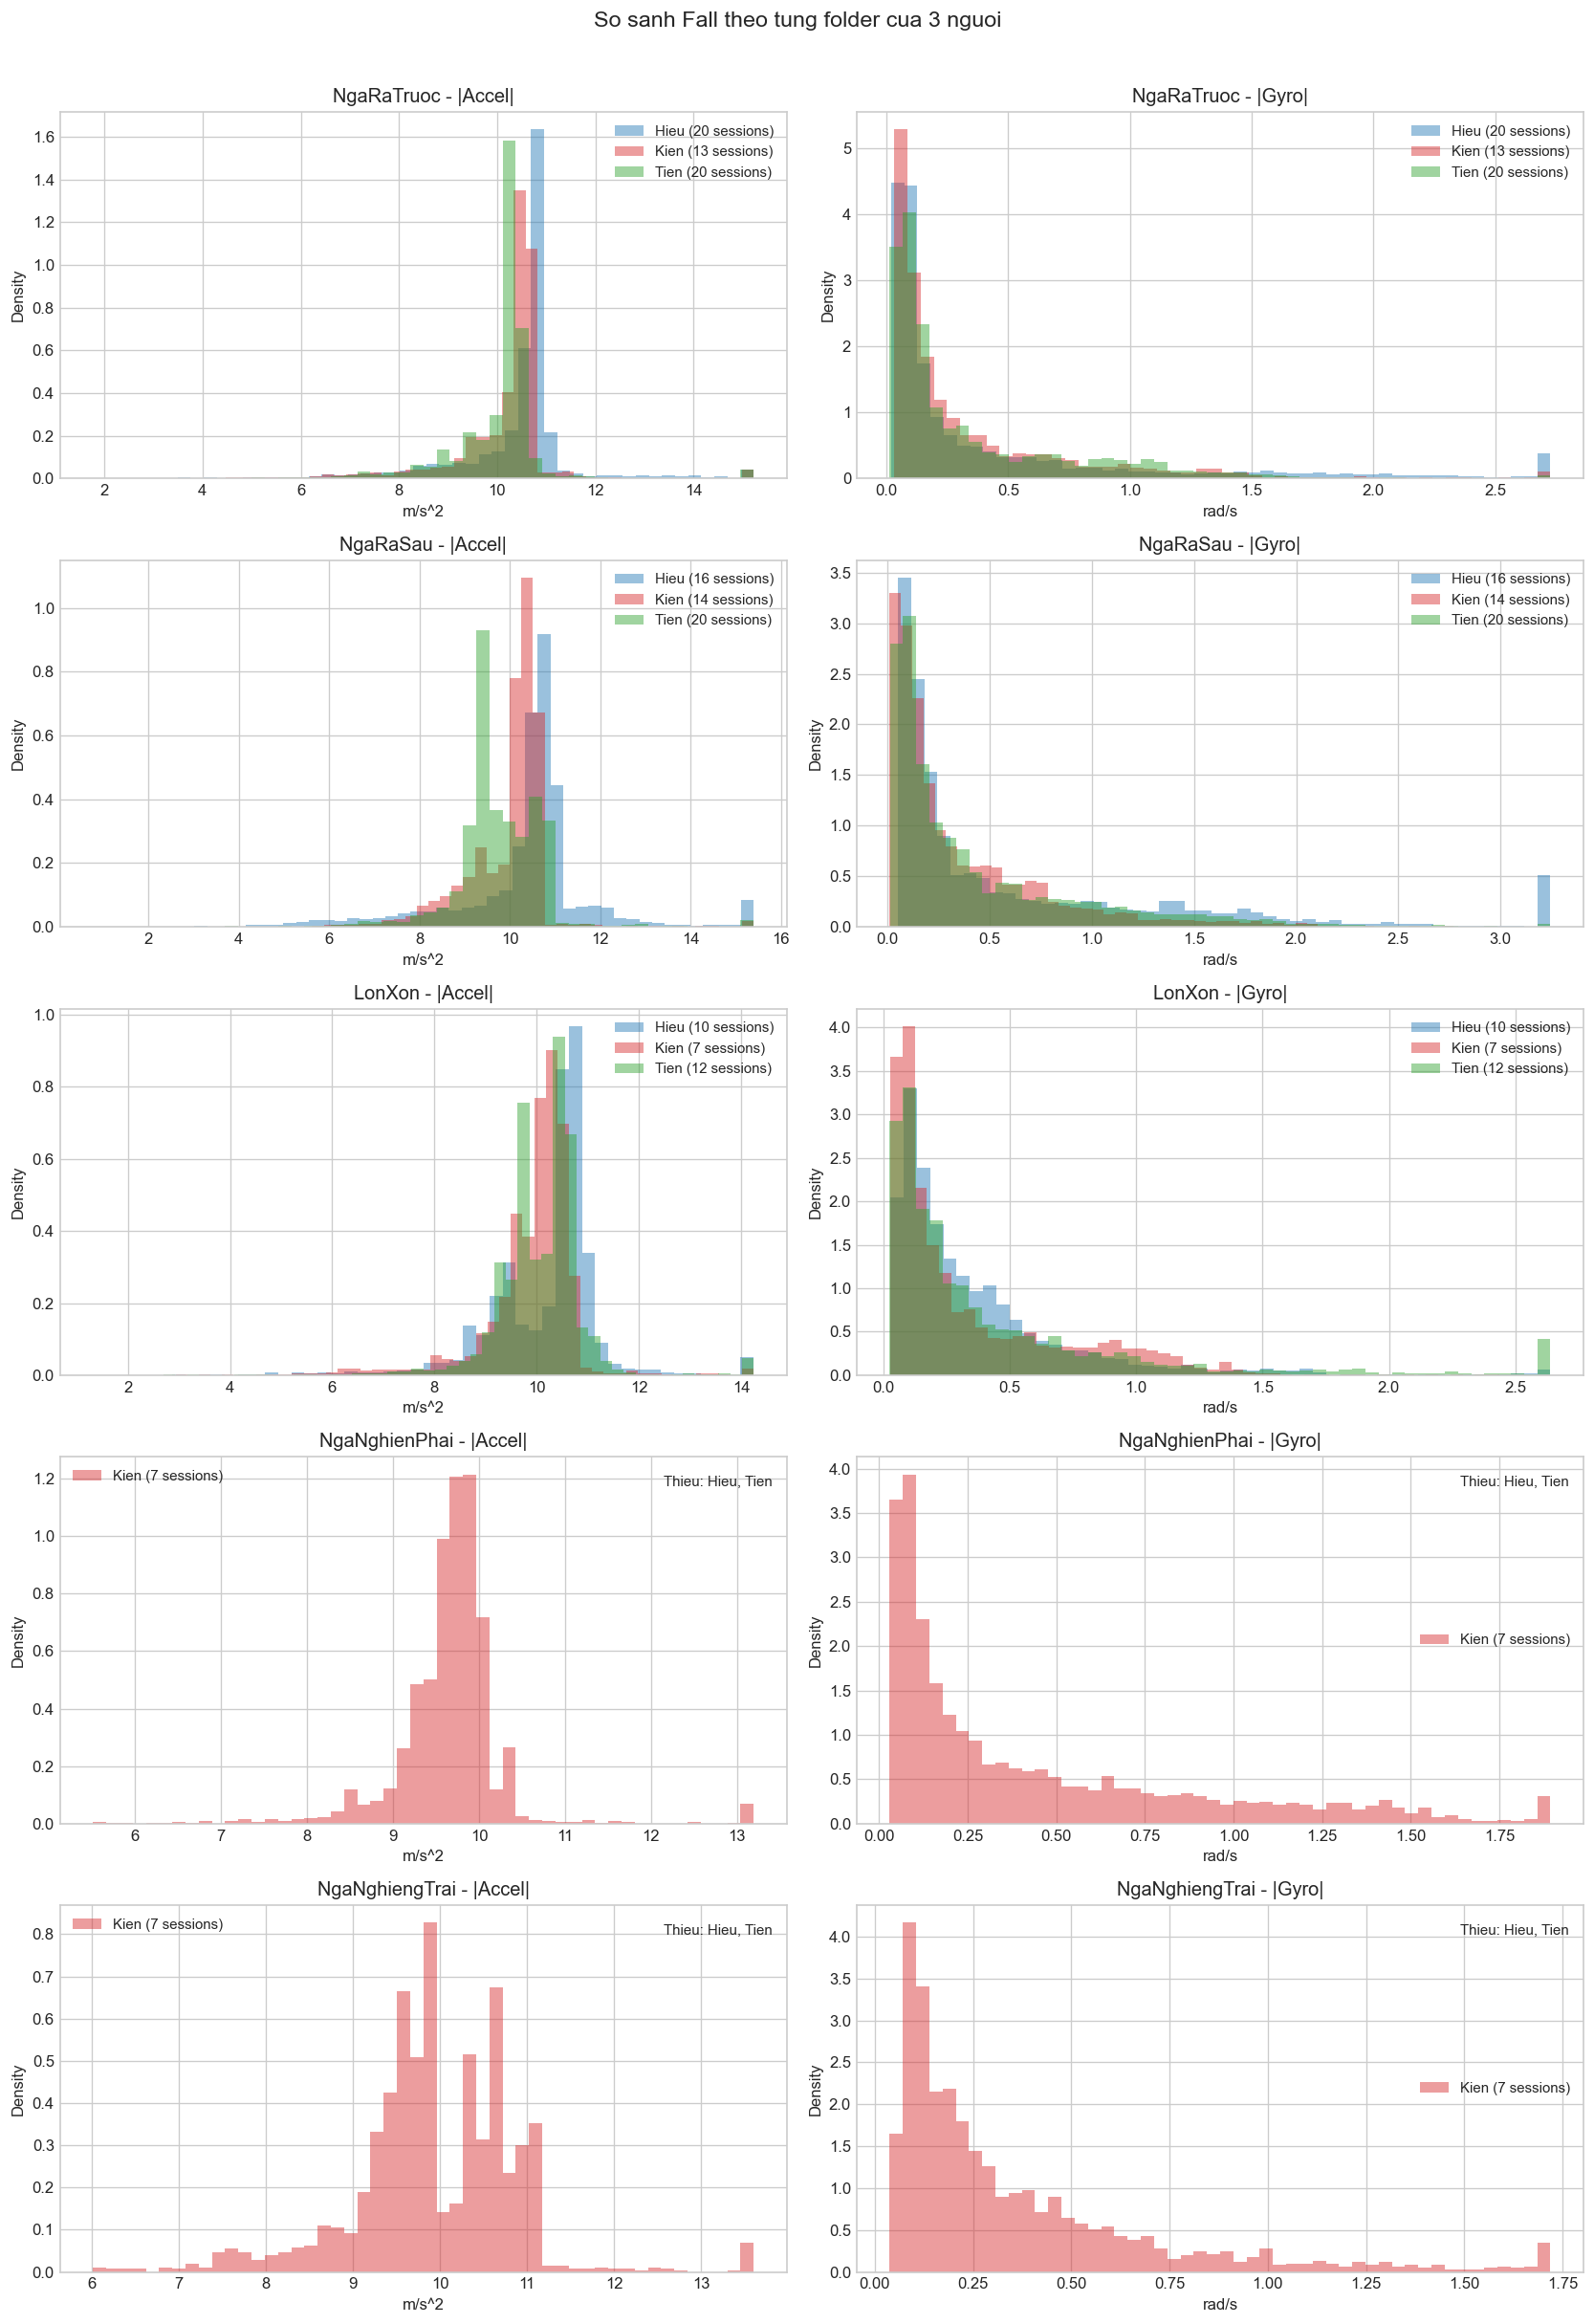

In [8]:
def plot_activity_distribution_grid(label_type, activity_names, title):
    if not activity_names:
        print(f'Khong co du lieu {label_type}.')
        return

    fig, axes = plt.subplots(len(activity_names), 2, figsize=(14, max(4 * len(activity_names), 4)), squeeze=False)

    for row, activity_name in enumerate(activity_names):
        ax_accel, ax_gyro = axes[row]
        accel_pool = all_accel[(all_accel['label_type'] == label_type) & (all_accel['activity_name'] == activity_name)]
        gyro_pool = all_gyro[(all_gyro['label_type'] == label_type) & (all_gyro['activity_name'] == activity_name)]
        accel_clip = accel_pool['mag'].quantile(0.99) if not accel_pool.empty else 1.0
        gyro_clip = gyro_pool['gmag'].quantile(0.99) if not gyro_pool.empty else 1.0
        missing_people = []

        for person_name in PERSON_ORDER:
            accel_subset = accel_pool[accel_pool['person'] == person_name]
            gyro_subset = gyro_pool[gyro_pool['person'] == person_name]

            if accel_subset.empty and gyro_subset.empty:
                missing_people.append(person_name)
                continue

            session_count = all_sessions[
                (all_sessions['label_type'] == label_type)
                & (all_sessions['activity_name'] == activity_name)
                & (all_sessions['person'] == person_name)
            ]['session'].nunique()
            legend_label = f'{person_name} ({session_count} sessions)'

            if not accel_subset.empty:
                ax_accel.hist(
                    accel_subset['mag'].clip(upper=accel_clip),
                    bins=50,
                    density=True,
                    alpha=0.45,
                    color=COLOR_MAP[person_name],
                    edgecolor='none',
                    label=legend_label,
                )

            if not gyro_subset.empty:
                ax_gyro.hist(
                    gyro_subset['gmag'].clip(upper=gyro_clip),
                    bins=50,
                    density=True,
                    alpha=0.45,
                    color=COLOR_MAP[person_name],
                    edgecolor='none',
                    label=legend_label,
                )

        ax_accel.set_title(f'{activity_name} - |Accel|')
        ax_accel.set_xlabel('m/s^2')
        ax_accel.set_ylabel('Density')
        ax_gyro.set_title(f'{activity_name} - |Gyro|')
        ax_gyro.set_xlabel('rad/s')
        ax_gyro.set_ylabel('Density')

        if missing_people:
            note = 'Thieu: ' + ', '.join(missing_people)
            ax_accel.text(0.98, 0.95, note, ha='right', va='top', transform=ax_accel.transAxes, fontsize=9)
            ax_gyro.text(0.98, 0.95, note, ha='right', va='top', transform=ax_gyro.transAxes, fontsize=9)

        if ax_accel.get_legend_handles_labels()[0]:
            ax_accel.legend(fontsize=9)
        if ax_gyro.get_legend_handles_labels()[0]:
            ax_gyro.legend(fontsize=9)

    plt.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

fall_activities = ordered_activities('Fall', all_sessions[all_sessions['label_type'] == 'Fall']['activity_name'].unique())
plot_activity_distribution_grid('Fall', fall_activities, 'So sanh Fall theo tung folder cua 3 nguoi')


## So sánh `Normal` theo từng folder của 3 người

Ví dụ `DiBo`: so sánh dữ liệu đi bộ của cả 3 người. Tương tự cho `ChayBoCham`, `GoPhim`, `LuotDienThoai` và các folder `Normal` còn lại.


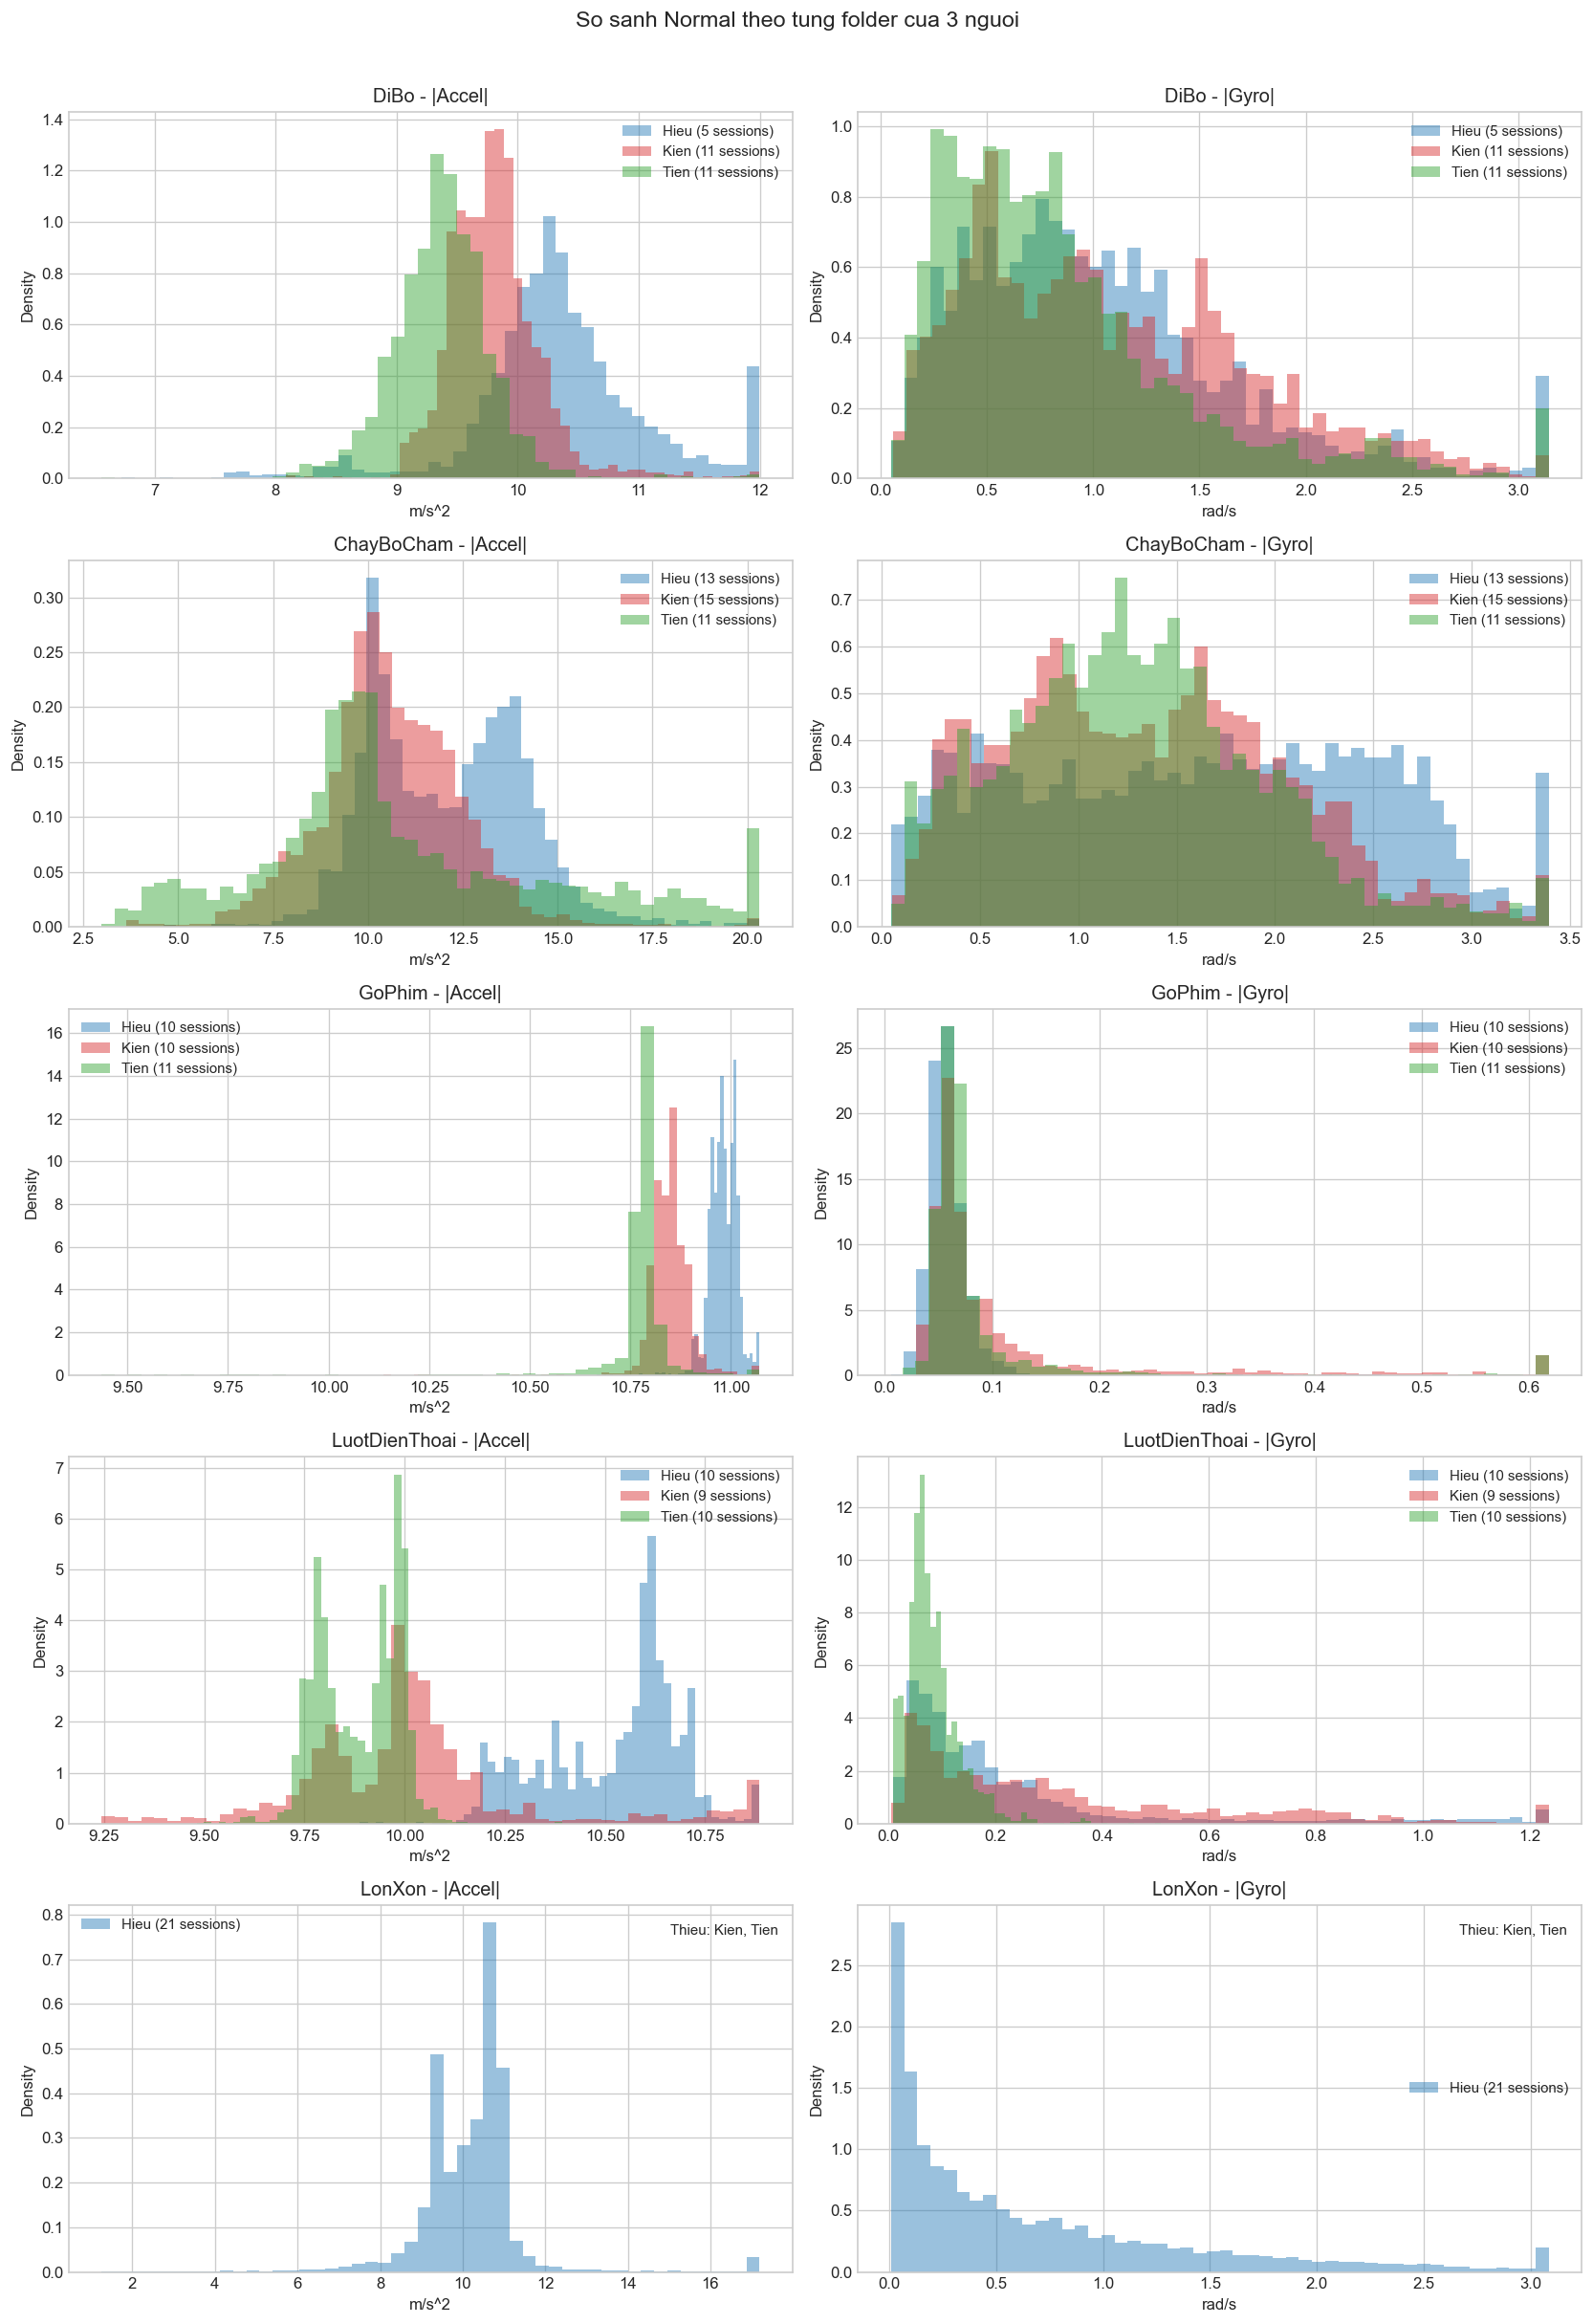

In [9]:
normal_activities = ordered_activities('Normal', all_sessions[all_sessions['label_type'] == 'Normal']['activity_name'].unique())
plot_activity_distribution_grid('Normal', normal_activities, 'So sanh Normal theo tung folder cua 3 nguoi')


## Bảng thống kê features theo activity

Cả `Fall` và `Normal` đều được thống kê theo từng folder để dễ đối chiếu giữa 3 người.


In [10]:
def summarize_features_by_activity(label_type):
    subset = all_features[all_features['label_type'] == label_type].copy()
    if subset.empty:
        return pd.DataFrame()

    usable_cols = [col for col in FEATURE_COLS if col in subset.columns]
    summary = (
        subset
        .groupby(['activity_name', 'person'])[usable_cols]
        .agg(['mean', 'median'])
        .round(3)
    )
    return summary

print('Fall features theo tung folder:')
display(summarize_features_by_activity('Fall'))

print('\nNormal features theo tung folder:')
display(summarize_features_by_activity('Normal'))


Fall features theo tung folder:


magnitude_avg            sma        max_accel          \
                               mean  median   mean median      mean  median   
activity_name  person                                                         
LonXon         Hieu          10.241  10.493  4.627  4.625    13.233  10.774   
               Kien           9.927  10.006  4.894  4.902    12.974  10.559   
               Tien          10.157  10.293  4.935  5.068    14.169  10.726   
NgaNghienPhai  Kien           9.684   9.644  5.031  4.978    12.381   9.985   
NgaNghiengTrai Kien           9.972   9.970  4.639  4.857    13.326  10.769   
NgaRaSau       Hieu          10.587  10.670  4.972  4.848    20.324  11.084   
               Kien           9.983  10.138  4.703  4.767    12.657  10.557   
               Tien           9.784   9.572  4.802  4.812    12.529  10.603   
NgaRaTruoc     Hieu          10.470  10.610  4.945  4.983    15.074  10.911   
               Kien          10.238  10.451  4.975  4.970    15.035  10.672   
               Tien          10.121  10.276  4.985  4.976    15.768  10.473   

                      max_gyro        std_accel        jerk_peak          \
                          mean median      mean median      mean  median   
activity_name  person                                                      
LonXon         Hieu      0.725  0.549     0.790  0.239   146.490   2.832   
               Kien      0.744  0.694     0.628  0.238   170.101   4.399   
               Tien      1.015  0.658     0.810  0.241   150.541   7.478   
NgaNghienPhai  Kien      1.038  1.277     0.507  0.195   100.445   4.506   
NgaNghiengTrai Kien      0.962  1.010     0.710  0.426   157.445   6.229   
NgaRaSau       Hieu      1.913  1.131     1.923  0.670   317.359  18.100   
               Kien      0.917  0.853     0.571  0.140   130.227   3.647   
               Tien      1.093  0.991     0.658  0.165   116.076   4.121   
NgaRaTruoc     Hieu      1.072  0.342     1.005  0.226   193.849   5.045   
               Kien      0.741  0.466     0.936  0.170   241.652   3.222   
               Tien      0.768  0.493     1.077  0.178   223.270   3.818   

                           bpm         
                          mean median  
activity_name  person                  
LonXon         Hieu     87.279   92.0  
               Kien    110.095  107.0  
               Tien     92.020   94.0  
NgaNghienPhai  Kien    100.857   96.0  
NgaNghiengTrai Kien     89.500   89.0  
NgaRaSau       Hieu     98.471   97.0  
               Kien     98.851  102.0  
               Tien    103.541  100.5  
NgaRaTruoc     Hieu    101.750  101.0  
               Kien    100.372  102.0  
               Tien     96.609   98.5


Normal features theo tung folder:


magnitude_avg            sma        max_accel          \
                              mean  median   mean median      mean  median   
activity_name person                                                         
ChayBoCham    Hieu          12.127  12.179  6.512  6.794    15.089  14.427   
              Kien          10.595  10.487  5.441  5.435    14.347  13.808   
              Tien          10.984  11.035  5.070  4.986    19.235  20.724   
DiBo          Hieu          10.399  10.355  5.503  5.464    11.693  11.049   
              Kien           9.808   9.842  4.736  4.679    10.466  10.254   
              Tien           9.375   9.382  4.686  4.681    10.045   9.902   
GoPhim        Hieu          10.983  10.983  4.904  4.888    11.030  11.009   
              Kien          10.850  10.850  4.397  4.422    10.987  10.916   
              Tien          10.772  10.789  5.429  5.438    10.908  10.816   
LonXon        Hieu          10.288  10.347  5.141  5.142    11.385  10.811   
LuotDienThoai Hieu          10.529  10.574  5.886  5.965    10.670  10.650   
              Kien          10.021   9.991  4.707  4.581    10.216  10.122   
              Tien           9.887   9.919  5.583  5.610     9.970   9.985   

                     max_gyro        std_accel        jerk_peak           \
                         mean median      mean median      mean   median   
activity_name person                                                       
ChayBoCham    Hieu      3.039  2.966     1.634  1.481    39.108   37.019   
              Kien      2.446  2.392     1.718  1.731    63.495   61.250   
              Tien      2.395  2.287     3.483  3.981   197.680  216.812   
DiBo          Hieu      2.186  2.010     0.596  0.354    10.490    6.369   
              Kien      2.178  2.189     0.275  0.200     9.399    3.982   
              Tien      1.675  1.443     0.318  0.248     9.161    5.863   
GoPhim        Hieu      0.110  0.078     0.017  0.006     1.477    0.511   
              Kien      0.225  0.140     0.039  0.023     4.534    2.510   
              Tien      0.198  0.083     0.049  0.011     3.150    0.752   
LonXon        Hieu      1.220  0.940     0.583  0.196    17.188    4.133   
LuotDienThoai Hieu      0.434  0.275     0.068  0.039     2.363    0.604   
              Kien      0.543  0.349     0.085  0.053     2.741    0.882   
              Tien      0.161  0.130     0.033  0.026     1.904    0.902   

                          bpm         
                         mean median  
activity_name person                  
ChayBoCham    Hieu     98.977   96.0  
              Kien     99.132   99.0  
              Tien     93.324   94.0  
DiBo          Hieu     90.714   95.0  
              Kien    103.000   99.0  
              Tien    101.579   98.0  
GoPhim        Hieu    104.122  103.0  
              Kien     93.667   97.0  
              Tien    103.226  101.0  
LonXon        Hieu     91.428   93.0  
LuotDienThoai Hieu    102.976  101.0  
              Kien    101.000   98.5  
              Tien    101.357  106.5

## So sánh time series trong cùng một người

Hai cặp hoạt động được so sánh:

- `DiBo` với `ChayBoCham`
- `LuotDienThoai` với `GoPhim`

Mỗi đường là median theo thời gian chuẩn hóa của nhiều session, vùng mờ là IQR để thấy độ dao động.


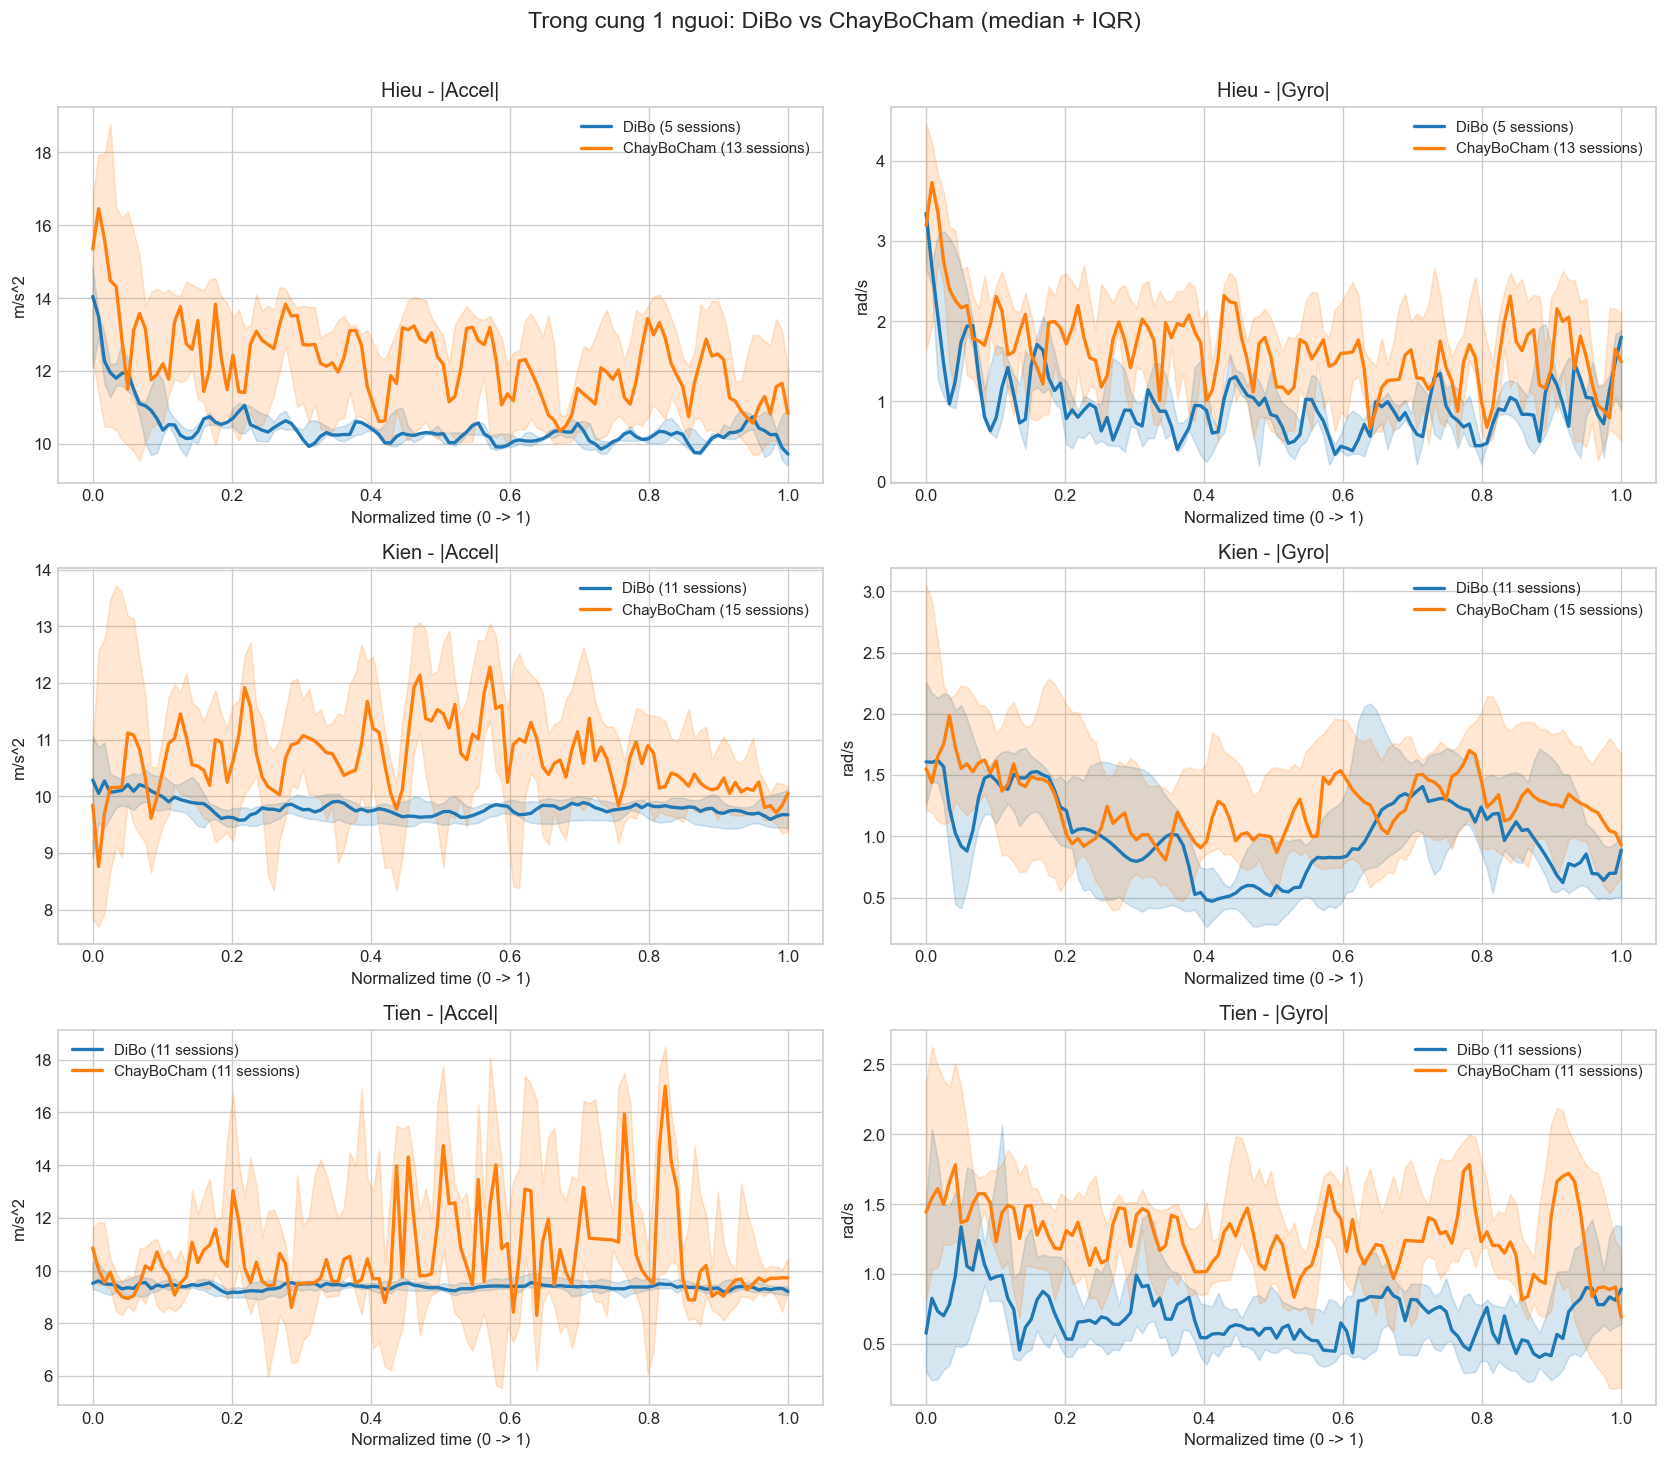

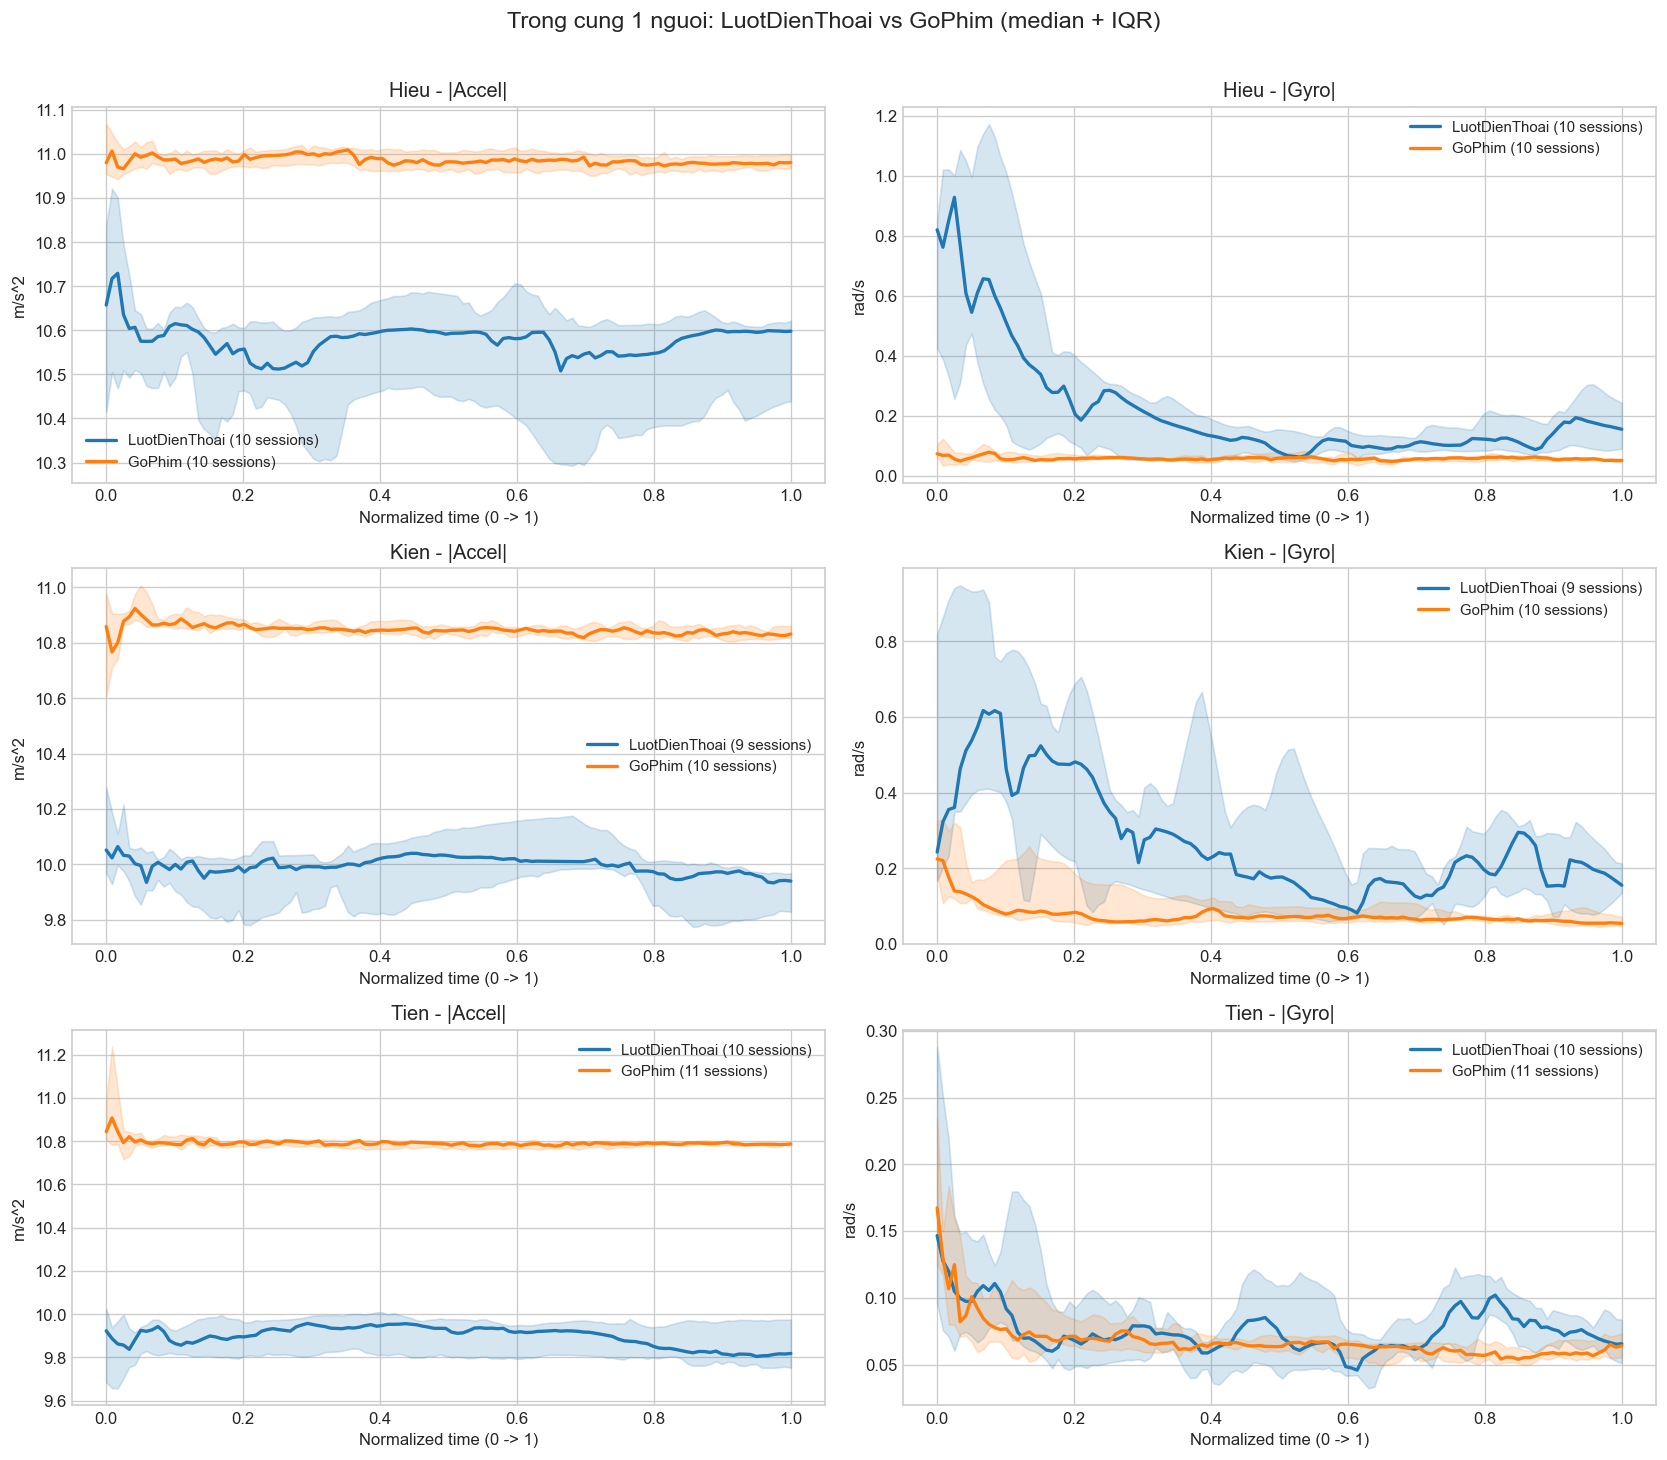

In [11]:
def resample_session_series(df, person_name, activity_name, value_col, n_points=120):
    subset = df[
        (df['person'] == person_name)
        & (df['label_type'] == 'Normal')
        & (df['activity_name'] == activity_name)
    ]
    if subset.empty:
        return None

    series_list = []
    target_x = np.linspace(0, 1, n_points)

    for session_name in subset['session'].unique():
        sess = subset[subset['session'] == session_name].sort_values('time')
        if len(sess) < 5:
            continue

        time_vals = sess['time'].to_numpy(dtype=float)
        value_vals = sess[value_col].to_numpy(dtype=float)
        time_vals = time_vals - time_vals.min()
        duration = time_vals.max()
        if duration <= 0:
            continue

        time_vals = time_vals / duration
        unique_x, unique_idx = np.unique(time_vals, return_index=True)
        unique_y = value_vals[unique_idx]
        if len(unique_x) < 3:
            continue

        series_list.append(np.interp(target_x, unique_x, unique_y))

    if not series_list:
        return None

    stacked = np.vstack(series_list)
    return {
        'x': target_x,
        'median': np.median(stacked, axis=0),
        'q25': np.quantile(stacked, 0.25, axis=0),
        'q75': np.quantile(stacked, 0.75, axis=0),
        'n_sessions': stacked.shape[0],
    }

def plot_pair_time_series(activity_a, activity_b, title):
    fig, axes = plt.subplots(len(PERSON_ORDER), 2, figsize=(14, 4 * len(PERSON_ORDER)), squeeze=False)
    activity_colors = {activity_a: '#1f77b4', activity_b: '#ff7f0e'}

    for row, person_name in enumerate(PERSON_ORDER):
        accel_ax, gyro_ax = axes[row]
        accel_missing = []
        gyro_missing = []

        for activity_name in [activity_a, activity_b]:
            accel_series = resample_session_series(all_accel, person_name, activity_name, 'mag')
            gyro_series = resample_session_series(all_gyro, person_name, activity_name, 'gmag')

            if accel_series is None:
                accel_missing.append(activity_name)
            else:
                label = f'{activity_name} ({accel_series["n_sessions"]} sessions)'
                accel_ax.plot(accel_series['x'], accel_series['median'], color=activity_colors[activity_name], linewidth=2, label=label)
                accel_ax.fill_between(accel_series['x'], accel_series['q25'], accel_series['q75'], color=activity_colors[activity_name], alpha=0.18)

            if gyro_series is None:
                gyro_missing.append(activity_name)
            else:
                label = f'{activity_name} ({gyro_series["n_sessions"]} sessions)'
                gyro_ax.plot(gyro_series['x'], gyro_series['median'], color=activity_colors[activity_name], linewidth=2, label=label)
                gyro_ax.fill_between(gyro_series['x'], gyro_series['q25'], gyro_series['q75'], color=activity_colors[activity_name], alpha=0.18)

        accel_ax.set_title(f'{person_name} - |Accel|')
        accel_ax.set_xlabel('Normalized time (0 -> 1)')
        accel_ax.set_ylabel('m/s^2')
        gyro_ax.set_title(f'{person_name} - |Gyro|')
        gyro_ax.set_xlabel('Normalized time (0 -> 1)')
        gyro_ax.set_ylabel('rad/s')

        if accel_ax.get_legend_handles_labels()[0]:
            accel_ax.legend(fontsize=9)
        if gyro_ax.get_legend_handles_labels()[0]:
            gyro_ax.legend(fontsize=9)

        if accel_missing:
            accel_ax.text(0.98, 0.95, 'Thieu: ' + ', '.join(accel_missing), ha='right', va='top', transform=accel_ax.transAxes, fontsize=9)
        if gyro_missing:
            gyro_ax.text(0.98, 0.95, 'Thieu: ' + ', '.join(gyro_missing), ha='right', va='top', transform=gyro_ax.transAxes, fontsize=9)

    plt.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

plot_pair_time_series('DiBo', 'ChayBoCham', 'Trong cung 1 nguoi: DiBo vs ChayBoCham (median + IQR)')
plot_pair_time_series('LuotDienThoai', 'GoPhim', 'Trong cung 1 nguoi: LuotDienThoai vs GoPhim (median + IQR)')
